# Chapter 17: Emerging Threats and Future Challenges

> "The threat landscape does not wait for defenders to catch up." security research community

---

## Learning Objectives

After completing this chapter, you will be able to:

1. Explain the post-quantum cryptography threat and the status of NIST PQC standardisation.
2. Describe AI-enabled attacks and AI-assisted defences.
3. Explain supply chain attacks and their significance.
4. Describe cloud-native security challenges and the shared responsibility model.
5. Explain threats to and from the Internet of Things.
6. Describe zero-day markets and responsible disclosure.
7. Discuss cyber-physical systems risks and the convergence of IT and OT.
8. Evaluate the impact of emerging technologies on the security threat landscape.

## Key Terms

- **Post-quantum cryptography (PQC)**: cryptographic algorithms resistant to quantum computers.
- **Shor's algorithm**: quantum algorithm that breaks RSA and ECC by factoring large numbers efficiently.
- **NIST PQC**: NIST's process for standardising post-quantum algorithms.
- **Supply chain attack**: compromising a target by attacking a trusted vendor, library, or update mechanism.
- **AI/ML in security**: using machine learning for both attack and defence.
- **LLM**: Large Language Model; AI capable of generating text including code, emails, and scripts.
- **Deepfake**: AI-generated synthetic audio, video, or image indistinguishable from real.
- **Zero-day**: a vulnerability unknown to the vendor; no patch exists.
- **Exploit broker**: organisations or individuals that buy and sell zero-day exploits.
- **Shared responsibility model**: cloud provider secures the infrastructure; customer secures their data and applications.
- **IoT**: Internet of Things; internet-connected embedded devices.
- **SBOM**: Software Bill of Materials; a list of software components in an application.

---

## Post-Quantum Cryptography

### The Quantum Threat to Current Cryptography

Classical computers cannot efficiently solve the problems underlying RSA (integer factorisation)
and ECC (elliptic curve discrete logarithm). Shor's algorithm, executable on a sufficiently
large, fault-tolerant quantum computer, solves both in polynomial time. A quantum computer of
sufficient scale would break all RSA and ECC keys, compromising TLS certificates, SSH keys,
VPN infrastructure, code-signing certificates, and any system using asymmetric cryptography.

### NIST PQC Standardisation

NIST launched a post-quantum cryptography standardisation process in 2016 and in 2024 published
the first three PQC standards:
- **ML-KEM** (CRYSTALS-Kyber): a key encapsulation mechanism based on module lattice problems.
- **ML-DSA** (CRYSTALS-Dilithium): a digital signature algorithm.
- **SLH-DSA** (SPHINCS+): a hash-based signature algorithm requiring no lattice assumptions.

A fourth standard, **FN-DSA** (FALCON), is also being finalised. These algorithms are designed
to resist both classical and quantum attacks and are intended to replace RSA and ECDSA over the
next decade.

#### Harvest Now, Decrypt Later

Adversaries are likely already collecting encrypted traffic today that they cannot decrypt with
current computers, planning to decrypt it once a quantum computer is available. Long-lived
secrets (state secrets, health data, legal records) encrypted today with RSA or ECC may be
readable in 10-15 years. This drives urgency for PQC migration even before quantum computers
are operational at scale.

---

## AI-Enabled Attacks and Defences

### Offensive AI

Large Language Models (LLMs) lower the barrier for several attack categories:

- **Phishing at scale**: LLMs generate personalised, grammatically perfect spear-phishing emails
  from LinkedIn data, eliminating the spelling errors that historically flagged phishing.
- **Social engineering scripts**: LLMs draft convincing vishing scripts tailored to specific targets.
- **Code generation**: LLMs assist in writing exploit code, fuzzing harnesses, and malware variants.
- **Deepfake fraud**: AI-generated audio and video impersonate executives for BEC and vishing;
  documented cases of deepfake CEO calls authorising wire transfers have been reported.

### Defensive AI

Machine learning provides significant defensive capability:

- **Anomaly detection**: ML models trained on normal behaviour detect deviations that
  signature-based tools miss.
- **Malware classification**: neural networks classify malware families from PE features or
  opcode sequences with high accuracy.
- **Natural language threat intelligence**: LLMs parse unstructured threat reports, extract
  IOCs, and map them to ATT&CK techniques faster than human analysts.
- **Automated triage**: SOAR platforms use ML to prioritise alerts and enrich them with context.

---

## Supply Chain Attacks

### Why Supply Chain Is a High-Value Target

Every organisation trusts dozens to thousands of software dependencies: open-source libraries,
commercial tools, cloud services, and managed service providers. Compromising a widely-used
library or update mechanism provides access to every consumer simultaneously.

### Notable Supply Chain Attack Patterns

#### Build Pipeline Compromise

The SolarWinds SUNBURST attack (2020) injected malicious code into the build pipeline, producing
a signed, legitimate-looking software update that installed a backdoor in approximately 18,000
organisations. The attacker had access to victim environments for months before detection.

#### Dependency Confusion and Typosquatting

Dependency confusion exploits the package manager resolution order: an attacker publishes a
public package with the same name as an organisation's internal package. The package manager
may prefer the public version, executing the attacker's code. Typosquatting registers packages
with names similar to popular ones (numpy vs numpyy) hoping developers mistype the dependency.

### SBOM and Dependency Management

A Software Bill of Materials (SBOM) enumerates every software component and its version in an
application. SBOM enables rapid assessment when a new vulnerability is published: which of our
applications include the vulnerable component? CISA and the White House Executive Order on
Cybersecurity (2021) mandate SBOM for software sold to the US federal government.

---

## Cloud Security

### The Shared Responsibility Model

Cloud providers secure the physical infrastructure, hypervisor, and managed services up to a
defined boundary. Customers are responsible for their data, identity and access management,
network configuration, and application security. Misunderstanding this boundary is a leading
cause of cloud security incidents.

#### Common Cloud Misconfigurations

- S3 buckets or Azure Blob Storage set to public read access.
- Overly permissive IAM roles (EC2 instances with AdministratorAccess).
- Security groups allowing inbound access from 0.0.0.0/0 on management ports.
- Secrets and API keys committed to public GitHub repositories.
- Logging disabled (CloudTrail, VPC Flow Logs).

### Cloud-Native Threats

Cloud environments introduce new attack surfaces: serverless function injection, container
escape from misconfigured Kubernetes clusters, abuse of cloud metadata services (IMDS) via
SSRF, and lateral movement via IAM role chaining.

---

## Internet of Things Security

### The IoT Attack Surface

IoT devices (smart cameras, thermostats, medical devices, industrial sensors) present a uniquely
difficult security challenge: they often run embedded Linux or RTOS with no patch mechanism, use
default credentials that are rarely changed, lack display or keyboard interfaces for security
configuration, and remain deployed for 10-20 years.

### Consequences

Compromised IP cameras have been used for botnet DDoS (Mirai botnet, 2016: 600 Gbps peak,
targeting Dyn DNS and disrupting major internet services). Compromised medical devices could
alter drug dosages or monitoring alarms. Compromised building systems could affect physical
security or HVAC of data centres. The consequence spectrum for IoT compromise extends from
nuisance to physical harm.

---

## Zero-Day Markets and Disclosure

### The Zero-Day Economy

Zero-day vulnerabilities in widely-used software are bought and sold for substantial sums.
Government agencies and private brokers pay millions of dollars for reliable, weaponisable
zero-days in iOS, Android, Windows, and popular browsers. This creates economic disincentive
for responsible disclosure and means some vulnerabilities are exploited as intelligence tools
for years before becoming public knowledge.

### Responsible Disclosure and Bug Bounties

Bug bounty programmes (HackerOne, Bugcrowd, and vendor-operated programmes) pay researchers
for vulnerabilities reported responsibly. Google's Project Zero enforces a 90-day disclosure
deadline: if a vendor does not patch within 90 days, the vulnerability is published regardless.
This creates patch pressure while giving vendors a reasonable remediation window.

---

## Why This Matters

The threat landscape is not static. An organisation that correctly implements the controls from
earlier chapters of this book is protected against the threat landscape of today. The controls
needed for tomorrow (PQC migration, AI-resistant phishing training, SBOM management, cloud
security posture management) must be planned now. Security programmes that monitor emerging
threats and adapt continuously are more resilient than those that deploy controls once and
consider the job done.

---

## News in Focus

NIST's publication of the first three post-quantum cryptographic standards in 2024 began the
largest coordinated cryptographic migration in internet history. Major TLS implementations
and cloud providers began deploying hybrid classical/PQC key exchange (combining ECDHE with
ML-KEM) to provide protection even before the full transition. Organisations with long-lived
sensitive data began cataloguing their cryptographic dependencies in preparation for migration.
This transition will take a decade and requires systematic cryptographic inventory and testing.

---


=== NIST PQC Standardised Algorithms (2024) ===

  Algorithm                 Use                    Hard Problem           Pub Key        Speed
  -----------------------------------------------------------------------------------------------
  ML-KEM (Kyber)            Key Encapsulation      Module Lattice         800-1568 B     Fast   [QUANTUM SAFE]
  ML-DSA (Dilithium)        Digital Signature      Module Lattice         1312-2592 B    Fast   [QUANTUM SAFE]
  SLH-DSA (SPHINCS+)        Digital Signature      Hash functions         32-64 B        Slower   [QUANTUM SAFE]
  FN-DSA (FALCON)           Digital Signature      NTRU Lattice           897-1793 B     Fast   [QUANTUM SAFE]
  RSA-2048 (classical)      Key Exchange/Sig       Integer factoring      256 B          Moderate   [VULNERABLE TO SHOR]
  ECDSA P-256 (classical)   Digital Signature      Elliptic curve DLP     64 B           Fast   [VULNERABLE TO SHOR]


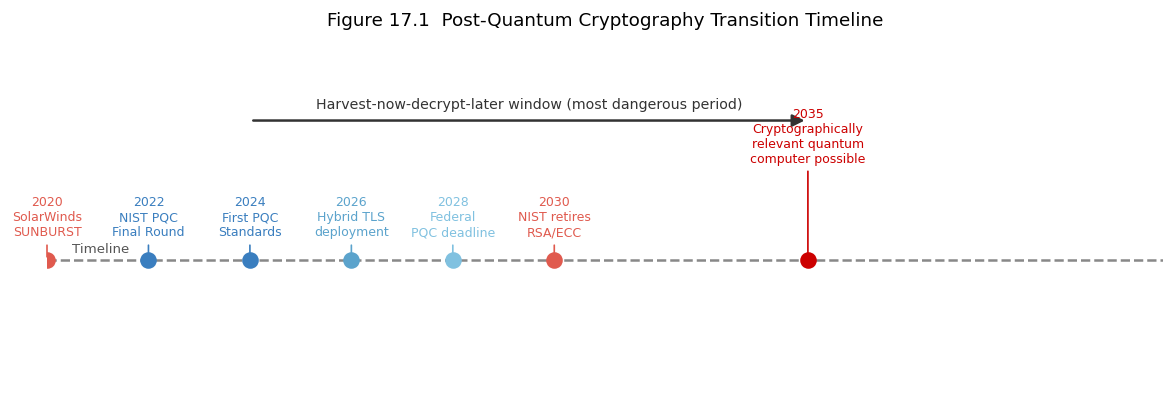

Figure 17.1 rendered.


In [1]:
# Chapter 17 -- Quantum threat timeline and PQC algorithm comparison

import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from io import BytesIO
from IPython.display import display, Image

# ── PQC algorithm comparison table ───────────────────────────────────────────
print("=== NIST PQC Standardised Algorithms (2024) ===\n")

algorithms = [
    dict(name="ML-KEM (Kyber)",       use="Key Encapsulation",
         basis="Module Lattice",      pub_size="800-1568 B", perf="Fast"),
    dict(name="ML-DSA (Dilithium)",   use="Digital Signature",
         basis="Module Lattice",      pub_size="1312-2592 B",perf="Fast"),
    dict(name="SLH-DSA (SPHINCS+)",   use="Digital Signature",
         basis="Hash functions",      pub_size="32-64 B",    perf="Slower"),
    dict(name="FN-DSA (FALCON)",      use="Digital Signature",
         basis="NTRU Lattice",        pub_size="897-1793 B", perf="Fast"),
    dict(name="RSA-2048 (classical)", use="Key Exchange/Sig",
         basis="Integer factoring",   pub_size="256 B",      perf="Moderate"),
    dict(name="ECDSA P-256 (classical)",use="Digital Signature",
         basis="Elliptic curve DLP",  pub_size="64 B",       perf="Fast"),
]

print(f"  {'Algorithm':<25} {'Use':<22} {'Hard Problem':<22} {'Pub Key':<14} {'Speed'}")
print("  " + "-"*95)
for a in algorithms:
    quantum = "QUANTUM SAFE" if "classical" not in a["name"] else "VULNERABLE TO SHOR"
    print(f"  {a['name']:<25} {a['use']:<22} {a['basis']:<22} {a['pub_size']:<14} {a['perf']}"
          + f"   [{quantum}]")

# ── Quantum threat timeline visualisation ─────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 4))
ax.axis("off"); ax.set_xlim(2020, 2042); ax.set_ylim(-1, 3.5)

events = [
    (2020, 0.3, "SolarWinds\nSUNBURST", "#e05a4e"),
    (2022, 0.3, "NIST PQC\nFinal Round", "#3a7ebf"),
    (2024, 0.3, "First PQC\nStandards", "#3a7ebf"),
    (2026, 0.3, "Hybrid TLS\ndeployment", "#5ba3cc"),
    (2028, 0.3, "Federal\nPQC deadline", "#80c1e0"),
    (2030, 0.3, "NIST retires\nRSA/ECC", "#e05a4e"),
    (2035, 1.2, "Cryptographically\nrelevant quantum\ncomputer possible", "#c00"),
]

ax.axhline(0.8, xmin=0, xmax=1, color="#888", lw=1.5, ls="--")
ax.text(2020.5, 0.9, "Timeline", fontsize=8, color="#555")

for year, y_off, label, color in events:
    ax.scatter([year], [0.8], color=color, s=80, zorder=5)
    ax.annotate(f"{year}\n{label}", xy=(year, 0.8),
                xytext=(year, 0.8 + y_off),
                ha="center", fontsize=7.5,
                arrowprops=dict(arrowstyle="-", color=color, lw=1),
                color=color)

ax.add_patch(mpatches.FancyArrowPatch((2024, 2.5), (2035, 2.5),
             arrowstyle="-|>", color="#333", lw=1.5, mutation_scale=15))
ax.text(2029.5, 2.65, "Harvest-now-decrypt-later window (most dangerous period)",
        ha="center", fontsize=8.5, color="#333")

ax.set_title("Figure 17.1  Post-Quantum Cryptography Transition Timeline", fontsize=11, pad=8)
ax.set_xlabel("Year", fontsize=9)
ax.set_xticks(range(2020, 2042, 2))

_buf = BytesIO()
plt.savefig(_buf, format="png", dpi=120, bbox_inches="tight")
plt.close(); _buf.seek(0)
display(Image(data=_buf.read()))
print("Figure 17.1 rendered.")


## Review Questions (MCQ)

**Q1.** Shor's algorithm threatens RSA and ECC by:
A. Brute-forcing the key space  B. Efficiently solving integer factorisation and discrete logarithm on a quantum computer  C. Exploiting TLS implementation bugs  D. Requiring the private key to be transmitted

**Q2.** The first NIST PQC standard for key encapsulation is:
A. FALCON  B. SPHINCS+  C. ML-KEM (Kyber)  D. ML-DSA (Dilithium)

**Q3.** "Harvest now, decrypt later" describes:
A. Storing data until quantum computers can break current encryption  B. Collecting credentials for password spraying  C. Archiving logs for forensic use  D. Caching TLS sessions

**Q4.** The SolarWinds attack is classified as a supply chain attack because:
A. It targeted the solar energy sector  B. Malicious code was injected into a trusted software update distributed to thousands of organisations  C. It used a zero-day in Windows  D. It targeted cloud infrastructure

**Q5.** An SBOM primarily helps an organisation:
A. Audit IAM permissions  B. Rapidly identify which products contain a newly disclosed vulnerable component  C. Generate YARA rules  D. Perform threat modelling

**Q6.** In the cloud shared responsibility model, the customer is always responsible for:
A. Physical server security  B. Hypervisor patches  C. Their data, identity management, and application security  D. Network hardware failures

**Q7.** The Mirai botnet primarily compromised:
A. Windows servers  B. IoT devices with default credentials  C. Cloud VMs  D. SCADA systems

**Q8.** LLMs improve spear phishing effectiveness primarily by:
A. Breaking TLS encryption  B. Generating personalised, grammatically correct phishing content at scale  C. Automating network scanning  D. Cracking passwords

**Q9.** Google Project Zero's 90-day disclosure policy is designed to:
A. Give attackers time to develop exploits  B. Allow indefinite vendor delay  C. Create patch pressure while giving vendors a reasonable remediation window  D. Prevent all public disclosure

**Q10.** Hybrid classical/PQC key exchange (e.g., ECDHE + ML-KEM) is deployed to:
A. Improve TLS performance  B. Provide protection during migration even if one algorithm is later broken  C. Eliminate certificate authorities  D. Reduce key sizes

*Answers: Q1 B, Q2 C, Q3 A, Q4 B, Q5 B, Q6 C, Q7 B, Q8 B, Q9 C, Q10 B.*

## Lab Assignment

**Part A -- Cryptographic inventory**: Audit a web service you control (your own server, a lab VM, or a cloud instance). Use `nmap --script ssl-enum-ciphers -p 443` to list the TLS cipher suites offered. Identify: which key exchange algorithm is used, whether it is forward-secret, and whether it uses a quantum-vulnerable algorithm.

**Part B -- PQC algorithm comparison**: Using the NIST PQC documentation, compare ML-KEM-768 and ML-KEM-1024 on four dimensions: public key size, ciphertext size, security level (NIST level), and performance. Explain the trade-off between ML-KEM-768 and ML-KEM-1024 for TLS deployment.

**Part C -- Supply chain risk assessment**: For a fictional organisation that uses 20 Python packages in a web application, describe the process for generating an SBOM using `pip-audit` or `cyclonedx-py`. Explain how you would use the SBOM to respond if a critical CVE were disclosed in one of those packages.

**Part D -- AI threat model**: Draft a one-page threat model for AI-enabled attacks on a 500-person financial services firm. Include: which roles are most vulnerable to AI-enhanced phishing/vishing, which defences are most effective (phishing-resistant MFA, deepfake detection, voice authentication review), and one emerging AI threat the firm should monitor.

## References

```{bibliography}
:filter: docname in docnames
```
